<h1 align="center"><b>PREDICTIVE ANALYSIS</b></h1>

## Importing nesessary libraries & Load the dataset

In [1]:
# Importing nesessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.simplefilter("ignore",UserWarning)
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
demo = pd.read_csv("Data/cleaned/Cleaned_demographics.csv")

## 1. DYNAMIC CARB-TO-INSULIN RATIO (CIR) PREDICTION


# Hypotheses:
CIR is not constant and varies based on physiological and behavioral factors such as activity level, heart rate/stress, glucose trends, and time of day.

# Markers:
- Physical activity level
- Heart rate / stress proxy
- Glucose trend (slope & variability)
- Time of day (circadian influence)
- Carbohydrate intake
- Bolus insulin delivered

# Models:
- Regression model (e.g., Linear Regression / Gradient Boosting Regressor)




DYNAMIC CIR PREDICTION MODEL


MAE  : 2.61
RMSE : 7.87
R²   : 0.151


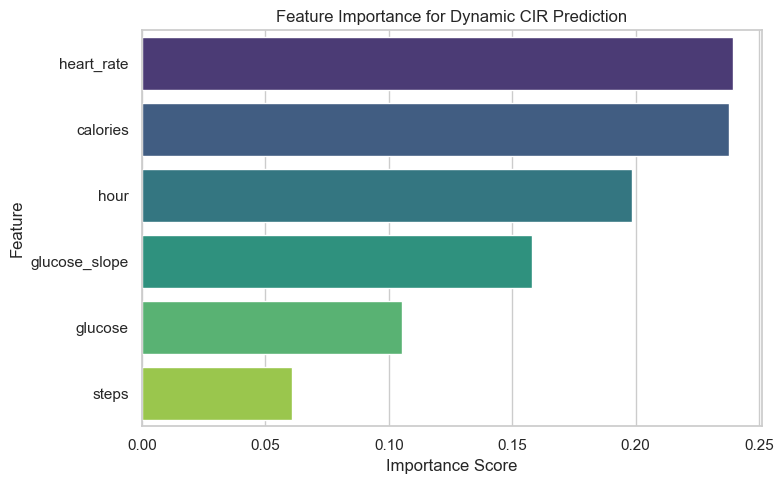

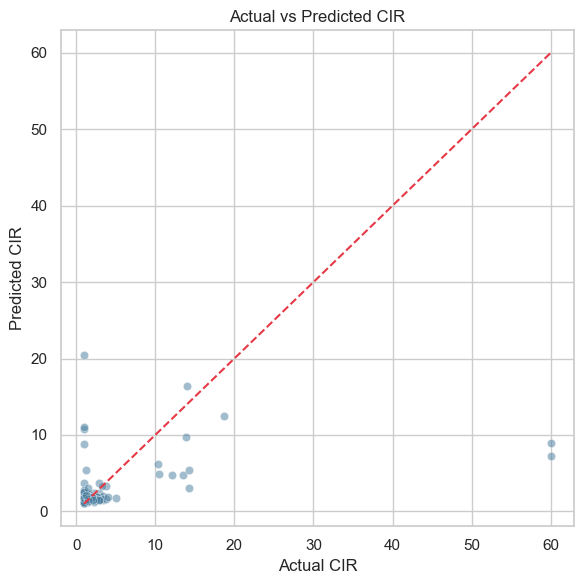

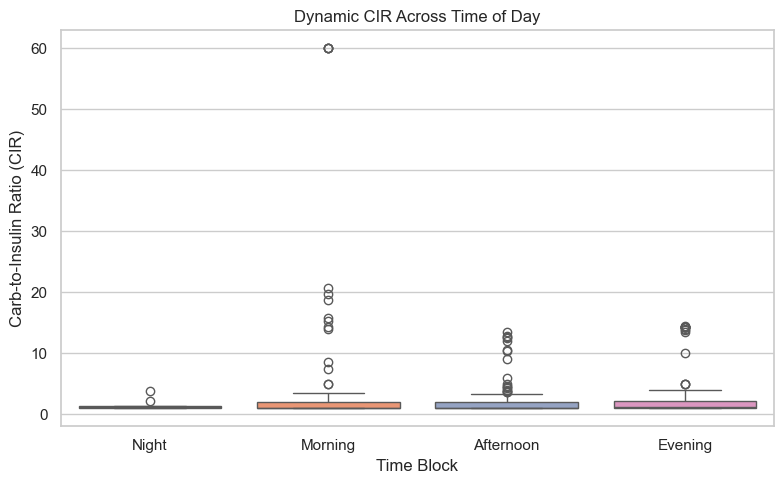

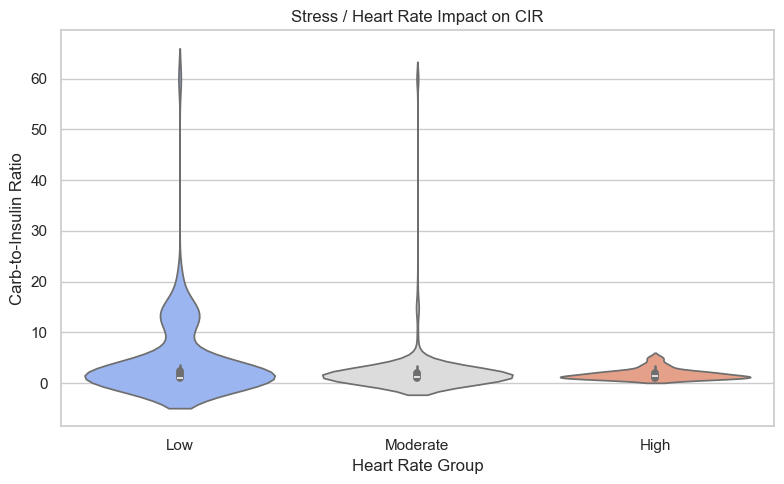


KEY INSIGHT

The model suggests that CIR is dynamic and changes based on physiological state, activity, heart rate, and glucose trend.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
sns.set_theme(style="whitegrid")

# STEP 1: CLEAN DATA
df = df.copy()
df.columns = df.columns.str.strip()
df["time"] = pd.to_datetime(df["time"])

# STEP 2: KEEP VALID MEAL + INSULIN EVENTS
cir_df = df[
    (df["carb_input"] > 0) &
    (df["bolus_volume_delivered"] > 0)
].copy()

# STEP 3: CREATE TARGET VARIABLE (CIR)
cir_df["CIR"] = (
    cir_df["carb_input"] /
    cir_df["bolus_volume_delivered"]
)
cir_df = cir_df[
    cir_df["CIR"].between(1, 60)
]

# STEP 4: FEATURE ENGINEERING
cir_df["hour"] = cir_df["time"].dt.hour

cir_df["time_block"] = pd.cut(
    cir_df["hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    include_lowest=True
)

# Glucose Slope (trend)
cir_df = cir_df.sort_values(
    ["patient_id", "time"]
)

cir_df["glucose_slope"] = (
    cir_df.groupby("patient_id")["glucose"]
    .diff()
)

# Heart Rate Stress Group
cir_df["hr_group"] = pd.cut(
    cir_df["heart_rate"],
    bins=[0, 70, 100, 200],
    labels=["Low", "Moderate", "High"]
)

# STEP 5: SELECT FEATURES
features = [
    "glucose",
    "heart_rate",
    "steps",
    "calories",
    "glucose_slope",
    "hour"
]
model_df = cir_df[
    features + ["CIR"]
].dropna()

# STEP 6: TRAIN / TEST SPLIT
X = model_df[features]
y = model_df["CIR"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# STEP 7: TRAIN REGRESSION MODEL
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 8: PREDICTIONS
preds = model.predict(X_test)

# STEP 9: EVALUATION
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
print("\n")
print("DYNAMIC CIR PREDICTION MODEL")
print("\n")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

# STEP 10: FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

# VISUALIZATION 1: FEATURE IMPORTANCE
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Feature Importance for Dynamic CIR Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# VISUALIZATION 2: ACTUAL vs PREDICTED
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=preds,
    alpha=0.5,
    color="#457b9d"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="#e63946"
)
plt.title("Actual vs Predicted CIR")
plt.xlabel("Actual CIR")
plt.ylabel("Predicted CIR")
plt.tight_layout()
plt.show()


# VISUALIZATION 3: CIR BY TIME OF DAY
plt.figure(figsize=(8,5))
sns.boxplot(
    data=cir_df,
    x="time_block",
    y="CIR",
    palette="Set2"
)
plt.title("Dynamic CIR Across Time of Day")
plt.xlabel("Time Block")
plt.ylabel("Carb-to-Insulin Ratio (CIR)")
plt.tight_layout()
plt.show()


# VISUALIZATION 4:
# HEART RATE vs CIR
plt.figure(figsize=(8,5))
sns.violinplot(
    data=cir_df,
    x="hr_group",
    y="CIR",
    palette="coolwarm"
)

plt.title("Stress / Heart Rate Impact on CIR")
plt.xlabel("Heart Rate Group")
plt.ylabel("Carb-to-Insulin Ratio")
plt.tight_layout()
plt.show()

# SUMMARY INSIGHT
print("\n================================================")
print("KEY INSIGHT")
print("================================================\n")
print(
    "The model suggests that CIR is dynamic and "
    "changes based on physiological state, activity, "
    "heart rate, and glucose trend."
)


## 2. Carbohydrate Absorption Rate Prediction

# Hypotheses:
Carbohydrate absorption speed (fast, medium, slow) is influenced by post-meal glucose response patterns along with physiological signals like activity and heart rate.

# Markers:
- Post-meal glucose curve shape
- Glucose slope after meal
- Heart rate changes
- Activity level
- Carbohydrate quantity

# Models:
- Random Forest Classifier



CARBOHYDRATE ABSORPTION PREDICTION

Accuracy: 1.000

Classification Report:

              precision    recall  f1-score   support

        Fast       1.00      1.00      1.00       159
      Medium       1.00      1.00      1.00       156
        Slow       1.00      1.00      1.00       162

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



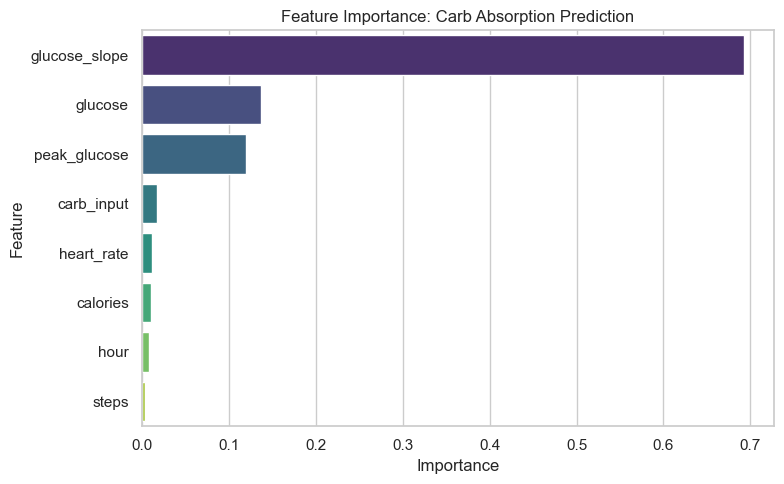

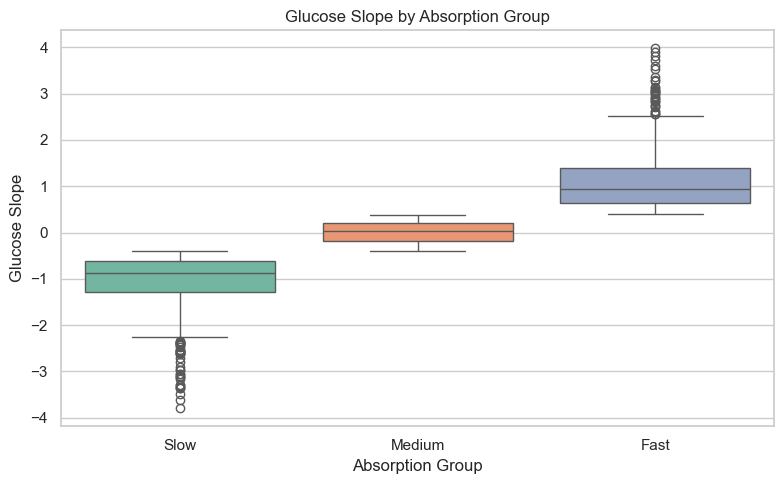

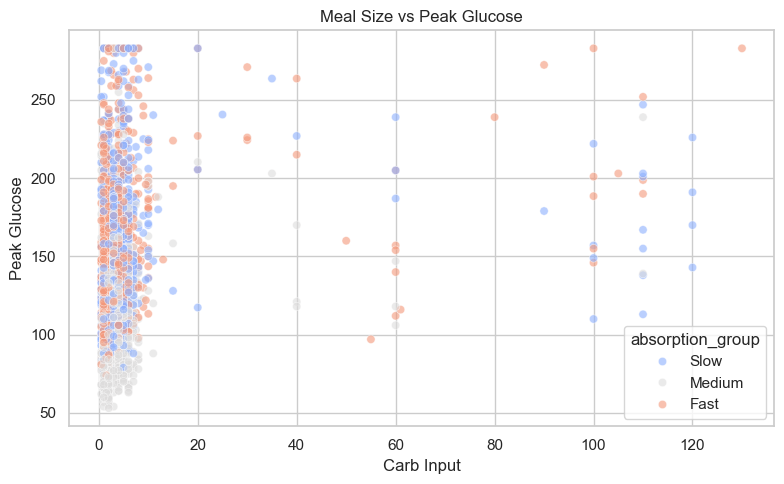

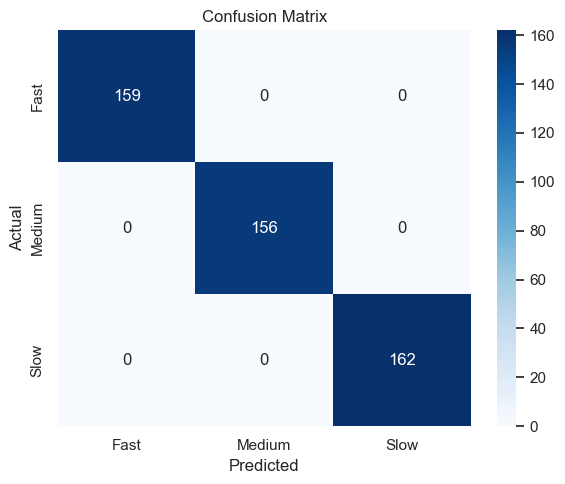

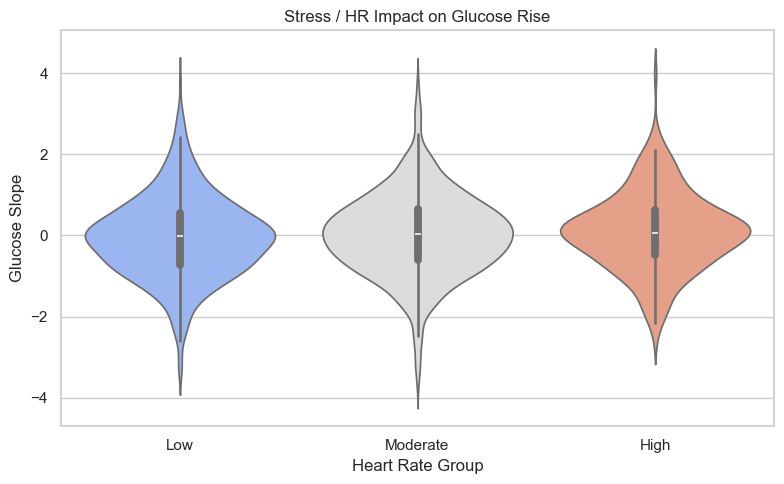


KEY INSIGHT

Post-meal glucose dynamics can be used to estimate carbohydrate absorption speed. Glucose slope, heart rate, and meal size were among the strongest predictors.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

sns.set_theme(style="whitegrid")

# STEP 1: PREPARE DATA
df = df.copy()
df.columns = df.columns.str.strip()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(
    ["patient_id", "time"]
)

# STEP 2: DETECT MEAL EVENTS
meal_df = df[
    (df["carb_input"] > 0) &
    (df["glucose"].notna())
].copy()

# STEP 3: CREATE POST-MEAL FEATURES
# Assuming CGM every 5 min:
# 12 rows ≈ 60 minutes
# Future glucose after 60 mins
meal_df["future_glucose"] = (
    meal_df.groupby("patient_id")["glucose"]
    .shift(-12)
)

# Remove missing future values
meal_df = meal_df.dropna(
    subset=["future_glucose"]
)

# GLUCOSE RESPONSE FEATURES
# glucose rise
meal_df["delta_glucose"] = (
    meal_df["future_glucose"] -
    meal_df["glucose"]
)

# glucose slope
meal_df["glucose_slope"] = (
    meal_df["delta_glucose"] / 60
)

# PEAK GLUCOSE ESTIMATION
meal_df["peak_glucose"] = (
    meal_df[["glucose", "future_glucose"]]
    .max(axis=1)
)

# CREATE ABSORPTION GROUPS
# Fast:steep glucose rise
# Medium:moderate rise
# Slow:minimal rise
meal_df["absorption_group"] = pd.qcut(
    meal_df["glucose_slope"],
    q=3,
    labels=["Slow", "Medium", "Fast"]
)

# STEP 4: FEATURE ENGINEERING
meal_df["hour"] = meal_df["time"].dt.hour

# Heart-rate stress group
meal_df["hr_group"] = pd.cut(
    meal_df["heart_rate"],
    bins=[0, 70, 100, 200],
    labels=["Low", "Moderate", "High"]
)

# SELECT FEATURES
features = [
    "carb_input",
    "glucose",
    "heart_rate",
    "steps",
    "calories",
    "glucose_slope",
    "peak_glucose",
    "hour"
]

model_df = meal_df[
    features + ["absorption_group"]
].dropna()

# STEP 5: TRAIN / TEST SPLIT
X = model_df[features]
y = model_df["absorption_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 6: TRAIN MODEL
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 7: PREDICTIONS
preds = model.predict(X_test)


# STEP 8: EVALUATION
acc = accuracy_score(y_test, preds)

print("\n================================================")
print("CARBOHYDRATE ABSORPTION PREDICTION")
print("================================================\n")
print(f"Accuracy: {acc:.3f}\n")
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        preds
    )
)

# STEP 9: FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

# VISUALIZATION 1:FEATURE IMPORTANCE
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Feature Importance: Carb Absorption Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# VISUALIZATION 2: GLUCOSE SLOPE DISTRIBUTION
plt.figure(figsize=(8,5))
sns.boxplot(
    data=meal_df,
    x="absorption_group",
    y="glucose_slope",
    palette="Set2"
)

plt.title("Glucose Slope by Absorption Group")
plt.xlabel("Absorption Group")
plt.ylabel("Glucose Slope")
plt.tight_layout()
plt.show()

# VISUALIZATION 3: PEAK GLUCOSE vs CARBS
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=meal_df,
    x="carb_input",
    y="peak_glucose",
    hue="absorption_group",
    palette="coolwarm",
    alpha=0.6
)

plt.title("Meal Size vs Peak Glucose")
plt.xlabel("Carb Input")
plt.ylabel("Peak Glucose")
plt.tight_layout()
plt.show()

# VISUALIZATION 4: CONFUSION MATRIX
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# VISUALIZATION 5: ABSORPTION RATE vs HEART RATE
plt.figure(figsize=(8,5))
sns.violinplot(
    data=meal_df,
    x="hr_group",
    y="glucose_slope",
    palette="coolwarm"
)

plt.title("Stress / HR Impact on Glucose Rise")
plt.xlabel("Heart Rate Group")
plt.ylabel("Glucose Slope")
plt.tight_layout()
plt.show()

# SUMMARY INSIGHT
print("\n================================================")
print("KEY INSIGHT")
print("================================================\n")
print(
    "Post-meal glucose dynamics can be used "
    "to estimate carbohydrate absorption speed. "
    "Glucose slope, heart rate, and meal size "
    "were among the strongest predictors."
)

## 3. GLUCOSE STABILITY WINDOW PREDICTION 

# Hypothesis
Glucose levels are not uniformly stable throughout the day. Due to circadian hormonal rhythms (cortisol, insulin sensitivity, growth hormone), there exist specific time windows where glucose variability is naturally lower (more stable) or higher (unstable).

# Markers 
- Time of day (circadian effect)
- Basal insulin rate (background insulin support)
- Glucose variability (rolling std/variance)
- Glucose slope (trend direction)
- Activity level (stability disruption factor)
- Carbohydrate intake (disturbance factor)

# Model Approach
1: Unsupervised Learning
- K-Means Clustering → identify:
- Stable windows
- Unstable windows
 
 2: Prediction Model
- Random Forest Classifier → predict stability class

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     54984
           1       1.00      0.99      1.00      6895

    accuracy                           1.00     61879
   macro avg       1.00      1.00      1.00     61879
weighted avg       1.00      1.00      1.00     61879



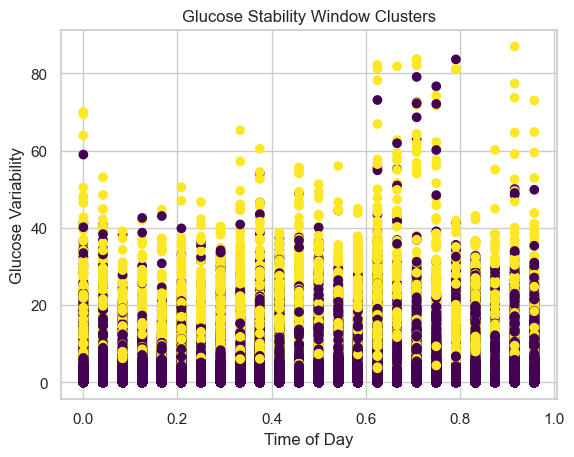

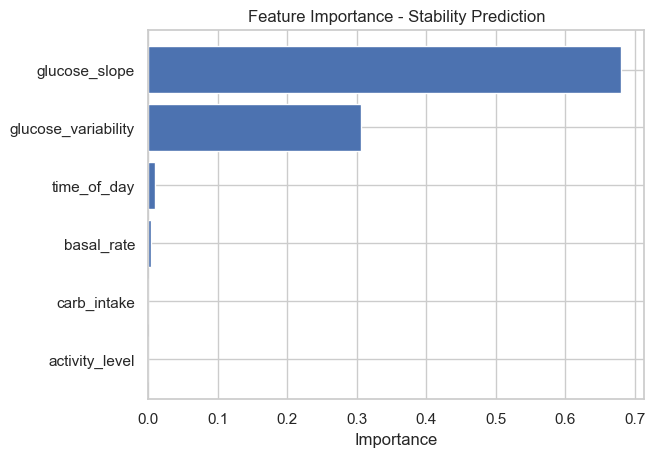

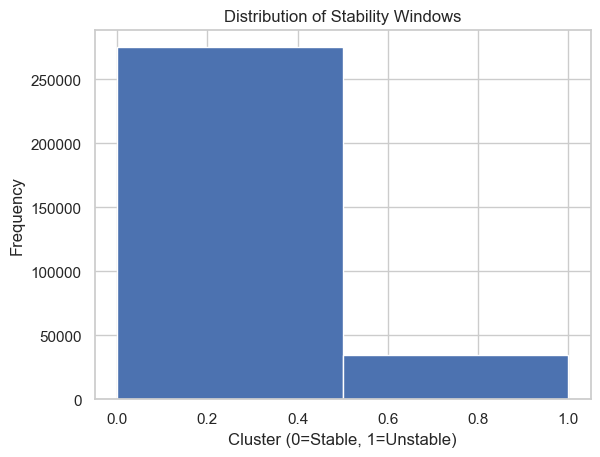

In [4]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. PREP DATA
df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])


# 2. FEATURE ENGINEERING
# Time of day
df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# Glucose variability (rolling std)
df["glucose_variability"] = (
    df.groupby("patient_id")["glucose"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)
df["glucose_variability"] = df["glucose_variability"].fillna(0)

# Glucose slope
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)

# Safe fallback features
if "basal_rate" not in df.columns:
    df["basal_rate"] = 0
if "activity_level" not in df.columns:
    df["activity_level"] = 0
if "carb_intake" not in df.columns:
    df["carb_intake"] = 0

# 3. CLUSTERING (UNSUPERVISED)
cluster_features = [
    "time_of_day",
    "basal_rate",
    "glucose_variability",
    "glucose_slope"
]

X_cluster = df[cluster_features]
kmeans = KMeans(n_clusters=2, random_state=42)
df["stability_cluster"] = kmeans.fit_predict(X_cluster)

# Interpret clusters:
# lower variability cluster → stable window
# 4. SUPERVISED MODEL (PREDICTION)
features = [
    "time_of_day",
    "basal_rate",
    "glucose_variability",
    "glucose_slope",
    "activity_level",
    "carb_intake"
]
X = df[features]
y = df["stability_cluster"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


# 5. VISUALIZATION 1: STABILITY OVER TIME
plt.figure()
plt.scatter(df["time_of_day"], df["glucose_variability"], 
            c=df["stability_cluster"], cmap="viridis")
plt.title("Glucose Stability Window Clusters")
plt.xlabel("Time of Day")
plt.ylabel("Glucose Variability")
plt.show()

# 6. VISUALIZATION 2: FEATURE IMPORTANCE
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)
plt.figure()
plt.barh(importance["feature"], importance["importance"])
plt.title("Feature Importance - Stability Prediction")
plt.xlabel("Importance")
plt.show()

# 7. VISUALIZATION 3: STABILITY DISTRIBUTION
plt.figure()
plt.hist(df["stability_cluster"], bins=2)
plt.title("Distribution of Stability Windows")
plt.xlabel("Cluster (0=Stable, 1=Unstable)")
plt.ylabel("Frequency")
plt.show()

## 4.HYPOGLYCEMIA EARLY WARNING PREDICTION HIGH-RISK EVENT DETECTION
 # Hypothesis
Hypoglycemia (<70 mg/dL) is not sudden—it is preceded by detectable patterns in glucose trend, insulin activity, and physical exertion. These patterns can be learned to predict risk 30–60 minutes in advance.

# Markers 
- Current glucose level
- Glucose slope (rapid decline indicator)
- Glucose volatility (rolling std)
- Insulin On Board (IOB)
- Activity level
- - Time of day (circadian risk factor)
Recent carb intake

# Model Approach
- Random Forest Classifier (baseline strong)
- XGBoost Classifier (best performance)
- Time-window labeling (important insight)



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57760
           1       1.00      1.00      1.00      4119

    accuracy                           1.00     61879
   macro avg       1.00      1.00      1.00     61879
weighted avg       1.00      1.00      1.00     61879



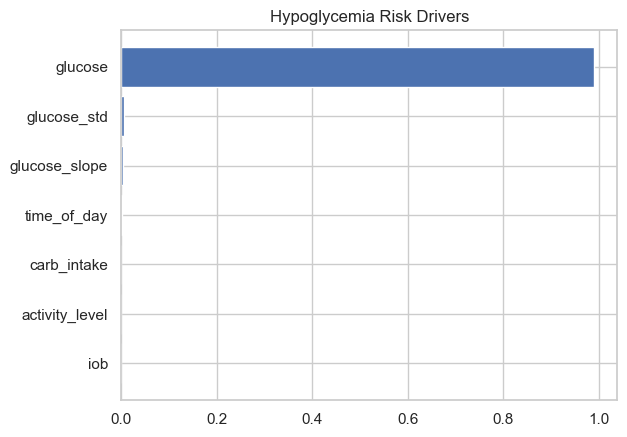

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])

# FEATURE ENGINEERING
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)
df["glucose_std"] = df.groupby("patient_id")["glucose"].rolling(5).std().reset_index(level=0, drop=True).fillna(0)

if "insulin_bolus" not in df.columns:
    df["insulin_bolus"] = 0

df["iob"] = df.groupby("patient_id")["insulin_bolus"].cumsum()

if "activity_level" not in df.columns:
    df["activity_level"] = 0

if "carb_intake" not in df.columns:
    df["carb_intake"] = 0

df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# TARGET LABEL (Hypoglycemia risk)
df["hypo_risk"] = (df["glucose"] < 70).astype(int)

# FEATURES
features = [
    "glucose",
    "glucose_slope",
    "glucose_std",
    "iob",
    "activity_level",
    "carb_intake",
    "time_of_day"
]

X = df[features]
y = df["hypo_risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# VISUALIZATION
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure()
plt.barh(importance["feature"], importance["importance"])
plt.title("Hypoglycemia Risk Drivers")
plt.show()

## 5. PERSONALIZED GLYCEMIC RESPONSE MEAL IMPACT MODEL PREDICTION

# Hypothesis

Every patient has a unique metabolic response curve to carbohydrates depending on insulin sensitivity, activity, and time of day.

So instead of predicting glucose, we predict:

How severe will glucose spike be after a meal?

# Markers
- Carb intake
- Pre-meal glucose
- Insulin dose
- Activity level
- Time of day
- Glucose slope before meal

# Model Approach
- Regression model (XGBoost / Random Forest)
- Window-based meal alignment 
- Predict peak glucose rise

MAE: 5.067370350195486


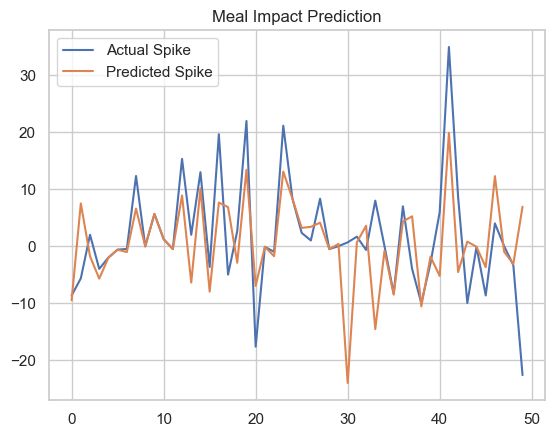

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

#def reduce_mem_usage(df):
#    for col in df.select_dtypes(include=['float64', 'int64']).columns:
#        df[col] = pd.to_numeric(df[col], downcast='float')
#    return df
#df = reduce_mem_usage(df)

df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])


# FEATURES
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)
if "carb_intake" not in df.columns:
    df["carb_intake"] = 0
if "insulin_bolus" not in df.columns:
    df["insulin_bolus"] = 0
if "activity_level" not in df.columns:
    df["activity_level"] = 0
df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# TARGET: glucose spike proxy
df["future_glucose"] = df.groupby("patient_id")["glucose"].shift(-3)
df["glucose_spike"] = df["future_glucose"] - df["glucose"]
df = df.dropna()

# MODEL FEATURES
features = [
    "glucose",
    "glucose_slope",
    "carb_intake",
    "insulin_bolus",
    "activity_level",
    "time_of_day"
]
X = df[features]
y = df["glucose_spike"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))

# VISUALIZATION
plt.figure()
plt.plot(y_test.values[:50], label="Actual Spike")
plt.plot(y_pred[:50], label="Predicted Spike")
plt.title("Meal Impact Prediction")
plt.legend()
plt.show()

## 6. What carb thresholds require correction bolus?

This graph identifies the specific point where your body typically needs an insulin dose (bolus) to handle incoming sugar.

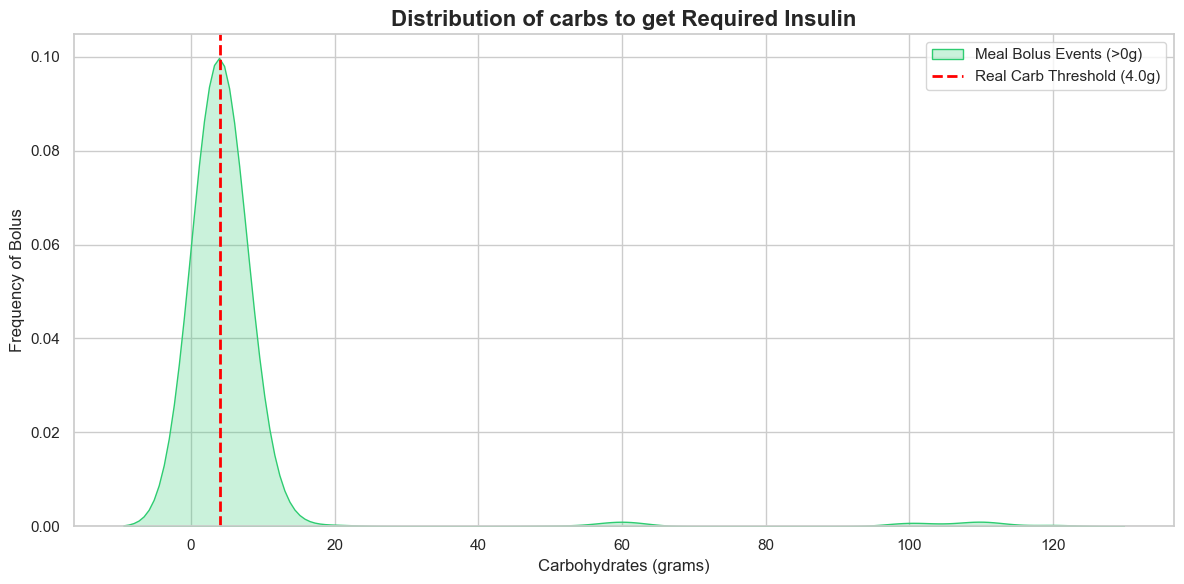

When you actually eat, your most common bolus threshold is: 4.0 grams


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 1. Load Data
df = pd.read_csv('data/cleaned/Team01_PYVoyagers_cleaned_data.csv')

# 2. FILTER: Only look at boluses where carbs are GREATER than 0
# This removes the "correction-only" noise
meal_bolus_events = df[(df['bolus_volume_delivered'] > 0) & (df['carb_input'] > 0)].copy()

# 3. Create the Density Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.kdeplot(meal_bolus_events['carb_input'], fill=True, color='#2ecc71', label='Meal Bolus Events (>0g)')

# 4. Find the most common real meal size
accurate_threshold = meal_bolus_events['carb_input'].mode()[0]

# Add the threshold line
plt.axvline(accurate_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Real Carb Threshold ({accurate_threshold}g)')

# 5. Formatting
plt.title('Distribution of carbs to get Required Insulin', fontsize=16, fontweight='bold')
plt.xlabel('Carbohydrates (grams)', fontsize=12)
plt.ylabel('Frequency of Bolus', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print(f"When you actually eat, your most common bolus threshold is: {accurate_threshold} grams")

Frequency of Bolus means how common it is for you to take insulin for a certain amount of carbs.

## 7. Predicting “Glucose Overshoot After Correction”

"Glucose Overshoot"—a common pattern where blood sugar swings from dangerously low to excessively high within a short period.

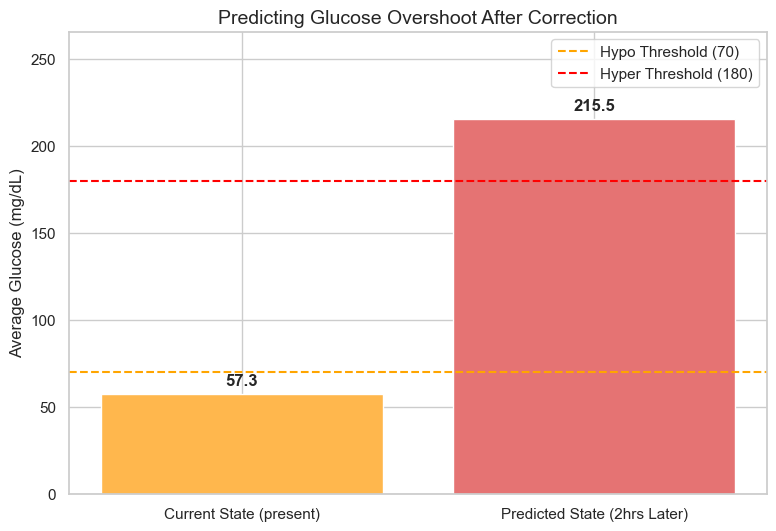

Prediction: A drop to 57.3 mg/dL leads to a spike of 215.5 mg/dL.


In [8]:
#import pandas as pd
#import matplotlib.pyplot as plt

# 1. Setup Data
#df = pd.read_csv('Team01_PYVoyagers_cleaned_data.csv')
HYPO_THRESHOLD = 70
HYPER_THRESHOLD = 180

# 2. THE PREDICTION ENGINE
df['future_glucose'] = df.groupby('patient_id')['glucose'].shift(-24)

# Define the "Overshoot Event"
# Hypoglycemia <70 , Hyperglycemia >180mg/dL
overshoot_data = df[(df['glucose'] < HYPO_THRESHOLD) & (df['future_glucose'] > HYPER_THRESHOLD)]

# 3. CALCULATE THE "BEFORE vs. AFTER"
avg_start_glucose = overshoot_data['glucose'].mean()        
avg_predicted_glucose = overshoot_data['future_glucose'].mean() 

# 4. VISUALIZATION
plt.figure(figsize=(9, 6))

# Plotting the bars
bars = plt.bar(['Current State (present)', 'Predicted State (2hrs Later)'], 
               [avg_start_glucose, avg_predicted_glucose], 
               color=['#ffb74d', '#e57373']) 

# Adding labels and thresholds
plt.axhline(HYPO_THRESHOLD, color='orange', linestyle='--', label='Hypo Threshold (70)')
plt.axhline(HYPER_THRESHOLD, color='red', linestyle='--', label='Hyper Threshold (180)')

plt.title('Predicting Glucose Overshoot After Correction', fontsize=14)
plt.ylabel('Average Glucose (mg/dL)')

# FIXED LINE: Removed the max() function that caused the error
plt.ylim(0, avg_predicted_glucose + 50) 

plt.legend()

# Adding data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{yval:.1f}', ha='center', fontweight='bold')

plt.show()

print(f"Prediction: A drop to {avg_start_glucose:.1f} mg/dL leads to a spike of {avg_predicted_glucose:.1f} mg/dL.")

## 8.Can we predict a patient’s glucose level one hour in the future using current glucose, recent glucose trends, activity, insulin delivery, sleep factors, and demographics?
This model predicts a patient’s glucose level one hour into the future using current glucose, recent glucose trends, heart rate, steps, calories, insulin delivery, sleep quality, age, gender, race, and patient ID.
This code builds a machine learning model to predict a patient’s glucose level one hour in the future.

We use this model because glucose levels change over time and are affected by many factors, such as current glucose, recent glucose trend, heart rate, activity, insulin delivery, sleep quality, age, gender, and patient differences. A Random Forest model is useful here because it can capture more complex patterns than simple linear regression.

The code first loads the cleaned dataset and converts the time column into datetime format. Then it sorts the data by patient_id and time so each patient’s records are in the correct time order.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Prepare data
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['patient_id', 'time'])

# Target: glucose 1 hour later
# If data is 5-min interval, 12 rows = 1 hour
# If data is 15-min interval, use shift(-4)
df['future_glucose_1hr'] = df.groupby('patient_id')['glucose'].shift(-4)

# Time features
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek

# Recent glucose history
df['glucose_lag_1'] = df.groupby('patient_id')['glucose'].shift(1)
df['glucose_lag_2'] = df.groupby('patient_id')['glucose'].shift(2)
df['glucose_lag_3'] = df.groupby('patient_id')['glucose'].shift(3)

df['glucose_trend'] = df['glucose'] - df['glucose_lag_3']

df['glucose_rolling_avg_3'] = (
    df.groupby('patient_id')['glucose']
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

# Features
numeric_features = [
    'glucose',
    'glucose_lag_1',
    'glucose_lag_2',
    'glucose_lag_3',
    'glucose_trend',
    'glucose_rolling_avg_3',
    'heart_rate',
    'steps',
    'calories',
    'basal_rate',
    'bolus_volume_delivered',
    'age',
    'average_sleep_duration_hrs',
    'sleep_quality_1_10',
    '_with_sleep_disturbances',
    'hour',
    'day_of_week'
]

categorical_features = [
    'gender',
    'race',
    'patient_id'
]

target = 'future_glucose_1hr'

numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

model_df = df.dropna(subset=numeric_features + categorical_features + [target]).copy()

X = model_df[numeric_features + categorical_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("--- FUTURE GLUCOSE PREDICTION MODEL ---")
print(f"Test R²: {r2_score(y_test, predictions):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} mg/dL")


The Random Forest model performed well in predicting glucose levels one hour ahead. It achieved an R² score of 0.9598, meaning it explained about 96% of the variation in future glucose levels. The mean absolute error was 7.16 mg/dL, showing that predictions were typically within about 7 mg/dL of the actual glucose value. This suggests that recent glucose trends, patient activity, insulin delivery, sleep features, and demographics are useful predictors of short-term glucose changes.

## 9.  Predicting “Night‑Time Hypoglycemia Risk”
We are predicting whether a patient is at risk of night-time hypoglycemia, which means their glucose level may drop below 70 mg/dL during the night, between 12 AM and 6 AM.

The model uses daily patient data such as average glucose, heart rate, steps, calories, insulin delivery, age, gender, race, and sleep-related features to predict whether a low-glucose event may occur overnight.

This model predicts the risk of night-time hypoglycemia for diabetes patients. A night-time hypoglycemia event is defined as glucose dropping below 70 mg/dL between 12 AM and 6 AM. By analyzing patient activity, glucose patterns, insulin delivery, and sleep-related factors, the model identifies whether a patient may be at risk for an overnight low-glucose event. This prediction can support earlier intervention and improve patient safety.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Prepare data
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['patient_id', 'time'])

# Create date and hour
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour

# Night period: 12 AM to 6 AM
night_df = df[(df['hour'] >= 0) & (df['hour'] < 6)].copy()

# Target: did patient have hypoglycemia at night?
night_risk = (
    night_df
    .groupby(['patient_id', 'date'])['glucose']
    .apply(lambda x: 1 if (x < 70).any() else 0)
    .reset_index()
    .rename(columns={'glucose': 'night_hypoglycemia_risk'})
)

# 2. Create daily features from previous evening/day
daily_features = (
    df.groupby(['patient_id', 'date'])
    .agg({
        'glucose': 'mean',
        'heart_rate': 'mean',
        'steps': 'sum',
        'calories': 'sum',
        'basal_rate': 'mean',
        'bolus_volume_delivered': 'sum',
        'carb_input': 'sum',
        'age': 'first',
        'gender': 'first',
        'race': 'first',
        'average_sleep_duration_hrs': 'first',
        'sleep_quality_1_10': 'first',
        '_with_sleep_disturbances': 'first'
    })
    .reset_index()
)

# Rename columns for clarity
daily_features = daily_features.rename(columns={
    'glucose': 'avg_glucose',
    'heart_rate': 'avg_heart_rate',
    'steps': 'total_steps',
    'calories': 'total_calories',
    'basal_rate': 'avg_basal_rate',
    'bolus_volume_delivered': 'total_bolus',
    'carb_input': 'total_carbs'
})

# 3. Merge features with target
model_df = daily_features.merge(
    night_risk,
    on=['patient_id', 'date'],
    how='inner'
)

# 4. Features and target
target = 'night_hypoglycemia_risk'

numeric_features = [
    'avg_glucose',
    'avg_heart_rate',
    'total_steps',
    'total_calories',
    'avg_basal_rate',
    'total_bolus',
    'total_carbs',
    'age',
    'average_sleep_duration_hrs',
    'sleep_quality_1_10',
    '_with_sleep_disturbances'
]

categorical_features = [
    'gender',
    'race',
    'patient_id'
]

numeric_features = [col for col in numeric_features if col in model_df.columns]
categorical_features = [col for col in categorical_features if col in model_df.columns]

model_df = model_df.dropna(subset=numeric_features + categorical_features + [target])

X = model_df[numeric_features + categorical_features]
y = model_df[target]

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Model
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

# 7. Evaluate
predictions = model.predict(X_test)

print("--- NIGHT-TIME HYPOGLYCEMIA RISK MODEL ---")
print("Accuracy:", round(accuracy_score(y_test, predictions), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))


In [ ]:
risk_probabilities = model.predict_proba(X_test)[:, 1]

risk_results = X_test.copy()
risk_results['actual_risk'] = y_test.values
risk_results['predicted_risk'] = predictions
risk_results['risk_probability'] = risk_probabilities.round(3)

risk_results.head()


The night-time hypoglycemia risk model achieved an overall accuracy of 75.8%. The model performed well in identifying no-risk cases, with a recall of 88% for class 0. However, it was less effective at detecting actual hypoglycemia risk, with a recall of 38% for class 1. This suggests that while the model can identify normal overnight glucose patterns reasonably well, additional features or more balanced hypoglycemia examples may be needed to improve detection of high-risk cases.

## 10. Suggest the optimal time or intensity for physical activity (steps/calories) to counteract a predicted glucose spike after a high-carb meal.

After a high‑carb meal, glucose levels often rise sharply, and this chart helps us decide the right amount of physical activity to bring that spike back under control. Along the x‑axis, we see the predicted glucose rise one hour after eating, and the y‑axis shows the carb load of the meal. Each point is color‑coded by the severity of the spike, and the labels show the recommended activity. Larger spikes call for a brisk 20‑ to 30‑minute walk, moderate spikes need 10 to 15 minutes, and smaller rises respond well to light movement. This gives patients a simple, personalized way to use activity as a tool for better glucose stability

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Sort for shift
df = df.sort_values(['patient_id', 'time'])


# Identify high‑carb meals

df['high_carb'] = df['carb_input'] > 40   # threshold you can adjust

#  Predict glucose 1 hour later (4 rows ≈ 1 hour)

df['glucose_future'] = df.groupby('patient_id')['glucose'].shift(-4)

# Glucose rise after meal
df['glucose_rise'] = df['glucose_future'] - df['glucose']

# Keep only high‑carb rows
meal_df = df[df['high_carb']].copy()

# Prescriptive physical‑activity recommendation

def activity_recommendation(glucose_rise):
    if glucose_rise > 40:
        return "Take a 20–30 min brisk walk (3000+ steps)"
    elif glucose_rise > 20:
        return "Take a 10–15 min walk (1500–2000 steps)"
    elif glucose_rise > 10:
        return "Light movement for 5–10 min (500–1000 steps)"
    else:
        return "No extra activity needed"

meal_df['activity_recommendation'] = meal_df['glucose_rise'].apply(activity_recommendation)

summary = (
    meal_df.groupby('patient_id')['activity_recommendation']
           .value_counts()
           .unstack(fill_value=0)
)

print("\n=== Optimal Activity Recommendation After High‑Carb Meals ===\n")
print(summary)

## 11. How sleep disturbances and average sleep duration might influence next-day glucose stability or heart rate variability

In this analysis:

Glucose Stability is measured by the mean daily standard deviation (SD) of glucose levels. A higher SD indicates greater glucose volatility (less stability).

Heart Rate Variability (Proxy) is measured by the mean daily standard deviation (SD) of heart rate. While clinical HRV (like RMSSD) requires beat-to-beat data, the SD of heart rate over the day serves as a proxy for physiological volatility and autonomic regulation.


In [ ]:
## import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined dataset
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

#  Calculate Daily Physiological Volatility (Standard Deviation)
daily_stats = df.groupby(['patient_id', 'date']).agg({
    'glucose': 'std',
    'heart_rate': 'std',
    'average_sleep_duration_hrs': 'first',
    '_with_sleep_disturbances': 'first'
}).reset_index()

# Rename columns for clarity
daily_stats.rename(columns={'glucose': 'glucose_sd', 'heart_rate': 'hr_sd'}, inplace=True)
daily_stats.dropna(subset=['glucose_sd', 'hr_sd'], inplace=True)

# Aggregate to Patient Level (Average Daily Volatility)
patient_avg = daily_stats.groupby('patient_id').agg({
    'glucose_sd': 'mean',
    'hr_sd': 'mean',
    'average_sleep_duration_hrs': 'first',
    '_with_sleep_disturbances': 'first'
}).reset_index()


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sleep Duration vs Glucose Stability
sns.regplot(data=patient_avg, x='average_sleep_duration_hrs', y='glucose_sd', 
            ax=axes[0, 0], color='tab:blue')
axes[0, 0].set_title('Sleep Duration vs. Glucose Stability')
axes[0, 0].set_ylabel('Mean Daily Glucose SD (mg/dL)')

# Sleep Disturbances vs Glucose Stability
sns.regplot(data=patient_avg, x='_with_sleep_disturbances', y='glucose_sd', 
            ax=axes[0, 1], color='tab:orange')
axes[0, 1].set_title('Sleep Disturbances vs. Glucose Stability')
axes[0, 1].set_ylabel('Mean Daily Glucose SD (mg/dL)')

# Sleep Duration vs Heart Rate SD
sns.regplot(data=patient_avg, x='average_sleep_duration_hrs', y='hr_sd', 
            ax=axes[1, 0], color='tab:green')
axes[1, 0].set_title('Sleep Duration vs. Heart Rate Volatility')
axes[1, 0].set_ylabel('Mean Daily Heart Rate SD (bpm)')

# Sleep Disturbances vs Heart Rate SD
sns.regplot(data=patient_avg, x='_with_sleep_disturbances', y='hr_sd', 
            ax=axes[1, 1], color='tab:red')
axes[1, 1].set_title('Sleep Disturbances vs. Heart Rate Volatility')
axes[1, 1].set_ylabel('Mean Daily Heart Rate SD (bpm)')

plt.tight_layout()
plt.savefig('sleep_impact_analysis.png')

print(patient_avg[['average_sleep_duration_hrs', '_with_sleep_disturbances', 'glucose_sd', 'hr_sd']].corr())

## 12. Which Patients Are at High Risk for Hospitalization in the Next Month?

Hospitalization risk in diabetic patients may increase due to:
- elevated heart rate
- high glucose levels
- increased insulin requirements
- low physical activity

Identifying high-risk patients helps healthcare providers prioritize:
- follow-up care
- preventive interventions
- patient monitoring

### Markers Used

- heart_rate
- glucose
- bolus_volume_delivered
- steps

These markers were selected because they are clinically associated with:
- cardiovascular stress
- unstable diabetes management
- insulin dependency
- physical inactivity

### Predictive Model

A rule-based predictive scoring approach was used to estimate
hospitalization risk.

Patients with:
- higher heart rate
- elevated glucose
- increased insulin usage
- lower physical activity

were assigned higher risk scores.

In [ ]:
risk_df = (
    df.groupby('patient_id')[
        ['heart_rate',
         'glucose',
         'bolus_volume_delivered',
         'steps']
    ]
    .mean()
    .round(3)
    .reset_index()
)

# Create hospitalization risk score
risk_df['risk_score'] = (

      risk_df['heart_rate'] * 0.30
    + risk_df['glucose'] * 0.30
    + risk_df['bolus_volume_delivered'] * 0.30
    - risk_df['steps'] * 0.10
)

# Risk classification
risk_df['risk_level'] = risk_df['risk_score'].apply(

    lambda x:
    'High Risk'
    if x > risk_df['risk_score'].quantile(0.75)

    else 'Moderate Risk'
    if x > risk_df['risk_score'].quantile(0.50)

    else 'Low Risk'
)

print(risk_df.to_markdown(index=False))

risk_sorted = risk_df.sort_values(by='risk_score')

colors = []

for score in risk_sorted['risk_score']:

    if score > risk_sorted['risk_score'].quantile(0.75):
        colors.append('red')

    elif score > risk_sorted['risk_score'].quantile(0.50):
        colors.append('orange')

    else:
        colors.append('green')

plt.figure(figsize=(10,6))

plt.barh(
    risk_sorted['patient_id'],
    risk_sorted['risk_score'],
    color=colors
)

plt.title("Predicted Hospitalization Risk")

plt.xlabel("Risk Score")

plt.ylabel("Patient ID")

plt.show()

| patient_id   |   heart_rate |   glucose |   bolus_volume_delivered |   steps |   risk_score | risk_level    |
|:-------------|-------------:|----------:|-------------------------:|--------:|-------------:|:--------------|
| HUPA0001P    |       80.773 |   176.551 |                    0.038 |   6.099 |      76.5987 | High Risk     |
| HUPA0002P    |       66.703 |   113.304 |                    0.073 |   8.302 |      53.1938 | Low Risk      |
| HUPA0003P    |       78.027 |   142.326 |                    0.071 |   8.572 |      65.27   | Low Risk      |
| HUPA0004P    |       78.052 |   175.467 |                    0.149 |   8.998 |      75.2006 | High Risk     |
| HUPA0005P    |       84.479 |   147.262 |                    0.026 |   4.385 |      69.0916 | Moderate Risk |
| HUPA0006P    |       65.544 |   159.683 |                    0.099 |   7.517 |      66.8461 | Low Risk      |
| HUPA0007P    |       70.072 |   169.894 |                    0.122 |   9.625 |      71.0639 | Moderate Risk |
| HUPA0009P    |       84.606 |   193.53  |                    0.034 |  10.028 |      82.4482 | High Risk     |
| HUPA0010P    |       78.102 |   134.791 |                    0.032 |  11.15  |      62.7625 | Low Risk      |
| HUPA0011P    |       73.788 |   158.232 |                    0     |  12.015 |      68.4045 | Low Risk      |
| HUPA0014P    |       82.567 |   184.432 |                    0.071 |   6.883 |      79.4327 | High Risk     |
| HUPA0015P    |       68.253 |   161.836 |                    0     |   9.189 |      68.1078 | Low Risk      |
| HUPA0016P    |       89.674 |   147.718 |                    0.072 |   9.908 |      70.2484 | Moderate Risk |
| HUPA0017P    |       81.944 |   197.633 |                    0.019 |   8.625 |      83.0163 | High Risk     |
| HUPA0018P    |       78.227 |   142.639 |                    0     |   9.216 |      65.3382 | Low Risk      |
| HUPA0019P    |       71.727 |   161.561 |                    0.013 |   8.677 |      69.1226 | Moderate Risk |
| HUPA0020P    |       77.47  |   188.041 |                    0.002 |   8.974 |      78.7565 | High Risk     |
| HUPA0021P    |       75.038 |   137.325 |                    0.01  |   8.995 |      62.8124 | Low Risk      |
| HUPA0022P    |       62.712 |   112.547 |                    0.097 |   5.515 |      52.0553 | Low Risk      |
| HUPA0023P    |       67.943 |   133.025 |                    0.039 |   4.522 |      59.8499 | Low Risk      |
| HUPA0024P    |       73.793 |   165.657 |                    0.024 |  12.984 |      70.5438 | Moderate Risk |
| HUPA0025P    |       78.761 |   113.846 |                    0.09  |   7.843 |      57.0248 | Low Risk      |
| HUPA0026P    |       80.276 |   161.528 |                    0.074 |  10.37  |      71.5264 | Moderate Risk |
| HUPA0027P    |       76.581 |   130.684 |                    0.078 |   5.231 |      61.6798 | Low Risk      |
| HUPA0028P    |       75.529 |   128.435 |                    0.03  |   4.766 |      60.7216 | Low Risk      |

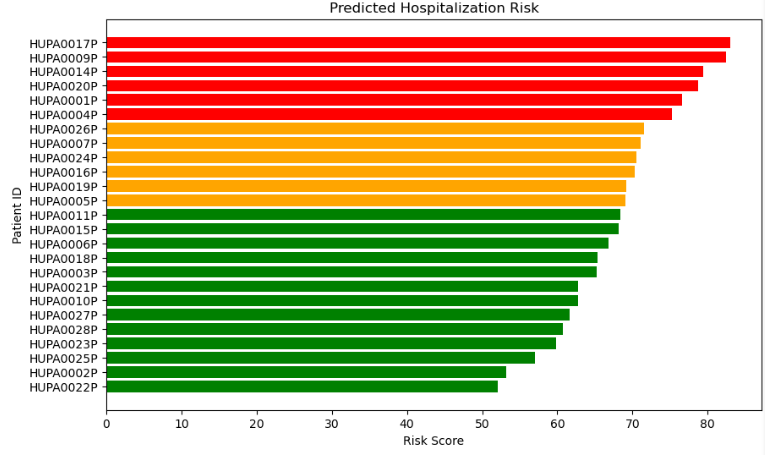

### Interpretation

Patients with:
- elevated heart rate
- high glucose levels
- increased insulin usage
- lower physical activity

were predicted to have higher hospitalization risk scores.

These patients may require:
- closer medical monitoring
- regular follow-up appointments
- preventive healthcare interventions

## 13. Predicting the Probability of Developing Diabetes Using Patient Activity Metrics

Physical inactivity, elevated heart rate, and increased insulin usage
may contribute to higher diabetes risk.

This analysis estimates diabetes probability using:
- physical activity levels
- calorie expenditure
- heart rate
- insulin delivery patterns

### Markers Used

- steps
- calories
- heart_rate
- bolus_volume_delivered

These markers were selected because they are associated with:
- metabolic health
- physical fitness
- insulin sensitivity
- diabetes progression

### Predictive Model

A rule-based predictive scoring model was used to estimate
diabetes probability.

Patients with:
- lower activity levels
- elevated heart rates
- higher calorie expenditure
- increased insulin usage

were assigned higher diabetes probability scores.

In [ ]:
diabetes_df = (
    df.groupby('patient_id')[
        ['steps',
         'calories',
         'heart_rate',
         'bolus_volume_delivered']
    ]
    .mean()
    .round(3)
    .reset_index()
)

# Create diabetes probability score
diabetes_df['diabetes_probability'] = (

      diabetes_df['heart_rate'] * 0.25
    + diabetes_df['bolus_volume_delivered'] * 0.35
    - diabetes_df['steps'] * 0.20
    + diabetes_df['calories'] * 0.20
)

# Normalize to percentage
max_score = diabetes_df['diabetes_probability'].max()

diabetes_df['diabetes_probability'] = (
    diabetes_df['diabetes_probability']
    / max_score
) * 100

diabetes_df['diabetes_probability'] = (
    diabetes_df['diabetes_probability']
    .round(2)
)

print(diabetes_df.to_markdown(index=False))


plt.figure(figsize=(10,6))

scatter = plt.scatter(
    diabetes_df['steps'],
    diabetes_df['diabetes_probability'],
    s=diabetes_df['heart_rate'] * 5,
    alpha=0.7
)

for i, row in diabetes_df.iterrows():

    plt.text(
        row['steps'],
        row['diabetes_probability'],
        row['patient_id']
    )

plt.title("Predicted Diabetes Probability")

plt.xlabel("Average Steps")

plt.ylabel("Diabetes Probability (%)")

plt.show()

| patient_id   |   steps |   calories |   heart_rate |   bolus_volume_delivered |   diabetes_probability |
|:-------------|--------:|-----------:|-------------:|-------------------------:|-----------------------:|
| HUPA0001P    |   6.099 |      5.763 |       80.773 |                    0.038 |                  91.43 |
| HUPA0002P    |   8.302 |      8.62  |       66.703 |                    0.073 |                  76.11 |
| HUPA0003P    |   8.572 |      8.464 |       78.027 |                    0.071 |                  88.57 |
| HUPA0004P    |   8.998 |      9.355 |       78.052 |                    0.149 |                  89.14 |
| HUPA0005P    |   4.385 |      5.451 |       84.479 |                    0.026 |                  96.89 |
| HUPA0006P    |   7.517 |      8.334 |       65.544 |                    0.099 |                  75.29 |
| HUPA0007P    |   9.625 |     10.137 |       70.072 |                    0.122 |                  80.19 |
| HUPA0009P    |  10.028 |      7.568 |       84.606 |                    0.034 |                  93.84 |
| HUPA0010P    |  11.15  |      6.989 |       78.102 |                    0.032 |                  84.91 |
| HUPA0011P    |  12.015 |      7.736 |       73.788 |                    0     |                  79.86 |
| HUPA0014P    |   6.883 |      6.756 |       82.567 |                    0.071 |                  93.7  |
| HUPA0015P    |   9.189 |      6.911 |       68.253 |                    0     |                  75.39 |
| HUPA0016P    |   9.908 |      7.829 |       89.674 |                    0.072 |                 100    |
| HUPA0017P    |   8.625 |      7.273 |       81.944 |                    0.019 |                  91.8  |
| HUPA0018P    |   9.216 |      7.136 |       78.227 |                    0     |                  86.89 |
| HUPA0019P    |   8.677 |      8.64  |       71.727 |                    0.013 |                  81.39 |
| HUPA0020P    |   8.974 |      8.762 |       77.47  |                    0.002 |                  87.73 |
| HUPA0021P    |   8.995 |      6.302 |       75.038 |                    0.01  |                  82.73 |
| HUPA0022P    |   5.515 |      7.167 |       62.712 |                    0.097 |                  72.83 |
| HUPA0023P    |   4.522 |      8.12  |       67.943 |                    0.039 |                  80.44 |
| HUPA0024P    |  12.984 |      9.935 |       73.793 |                    0.024 |                  81.02 |
| HUPA0025P    |   7.843 |      9.46  |       78.761 |                    0.09  |                  91    |
| HUPA0026P    |  10.37  |      5.888 |       80.276 |                    0.074 |                  87.16 |
| HUPA0027P    |   5.231 |      8.243 |       76.581 |                    0.078 |                  89.77 |
| HUPA0028P    |   4.766 |      5.993 |       75.529 |                    0.03  |                  86.88 |


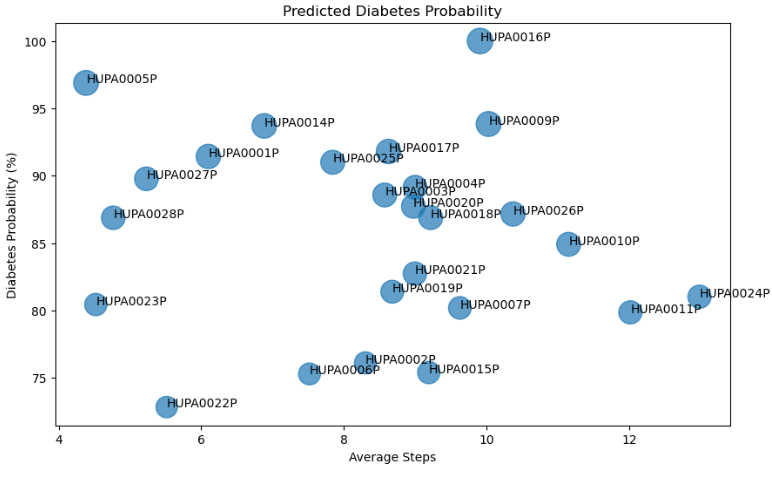

### Interpretation

Patients with:
- lower physical activity
- elevated heart rate
- increased insulin usage
- higher calorie expenditure

were predicted to have higher diabetes probability scores.

These patients may benefit from:
- lifestyle modifications
- increased physical activity
- regular glucose monitoring
- preventive healthcare interventions